In [47]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CatBoostClassifier = None
    CATBOOST_AVAILABLE = False

warnings.filterwarnings("ignore", category=RuntimeWarning)

RANDOM_STATE = 20260527
DATA_PATH = Path(r"C:\Users\shega\Documents\GitHub\ML_coursework_2026\data\secom.data")
LABELS_PATH = Path(r"C:\Users\shega\Documents\GitHub\ML_coursework_2026\data\secom_labels.data")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.precision", 4)

def section(title):
    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)

In [48]:
def load_secom(data_path=DATA_PATH, labels_path=LABELS_PATH):
    X = pd.read_csv(data_path, sep=r"\s+", header=None, na_values=["NaN"], engine="python")
    X.columns = [f"sensor_{i:03d}" for i in range(X.shape[1])]

    rows = []
    pattern = re.compile(r'^\s*(-?1)\s+"([^"]+)"\s*$')
    for line in labels_path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        match = pattern.match(line)
        if match is None:
            raise ValueError(f"Cannot parse label line: {line}")
        original_label = int(match.group(1))
        rows.append({
            "target_original": original_label,
            "target": 1 if original_label == 1 else 0,
            "timestamp": pd.to_datetime(match.group(2), format="%d/%m/%Y %H:%M:%S"),
        })

    labels = pd.DataFrame(rows)
    if len(X) != len(labels):
        raise ValueError(f"Feature rows ({len(X)}) != label rows ({len(labels)})")
    return X, labels["target"], labels

X_raw, y, labels = load_secom()

section("0. Загрузка данных")
display(X_raw.head())
display(labels.head())


0. Загрузка данных


,sensor_000,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005,sensor_006,sensor_007,sensor_008,sensor_009,sensor_010,sensor_011,sensor_012,sensor_013,sensor_014,sensor_015,sensor_016,sensor_017,sensor_018,sensor_019,sensor_020,sensor_021,sensor_022,sensor_023,sensor_024,sensor_025,sensor_026,sensor_027,sensor_028,sensor_029,sensor_030,sensor_031,sensor_032,sensor_033,sensor_034,sensor_035,sensor_036,sensor_037,sensor_038,sensor_039,sensor_040,sensor_041,sensor_042,sensor_043,sensor_044,sensor_045,sensor_046,sensor_047,sensor_048,sensor_049,sensor_050,sensor_051,sensor_052,sensor_053,sensor_054,sensor_055,sensor_056,sensor_057,sensor_058,sensor_059,...,sensor_530,sensor_531,sensor_532,sensor_533,sensor_534,sensor_535,sensor_536,sensor_537,sensor_538,sensor_539,sensor_540,sensor_541,sensor_542,sensor_543,sensor_544,sensor_545,sensor_546,sensor_547,sensor_548,sensor_549,sensor_550,sensor_551,sensor_552,sensor_553,sensor_554,sensor_555,sensor_556,sensor_557,sensor_558,sensor_559,sensor_560,sensor_561,sensor_562,sensor_563,sensor_564,sensor_565,sensor_566,sensor_567,sensor_568,sensor_569,sensor_570,sensor_571,sensor_572,sensor_573,sensor_574,sensor_575,sensor_576,sensor_577,sensor_578,sensor_579,sensor_580,sensor_581,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,0.0,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,0.8955,1.7730,3.0490,64.2333,2.0222,0.1632,3.5191,83.3971,9.5126,50.6170,64.2588,49.3830,66.3141,86.9555,117.5132,61.29,4.515,70.0,352.7173,10.1841,130.3691,723.3092,1.3072,141.2282,1.0,624.3145,218.3174,0.0,4.592,4.841,2834.0,0.9317,0.9484,4.7057,-1.7264,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0570,4.0825,11.5074,0.1096,0.0078,0.0026,7.116,1.0616,395.570,75.752,0.4234,12.93,0.78,0.1827,5.7349,0.3363,39.8842,3.2687,1.0297,1.0344,0.4385,0.1039,42.3877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533.8500,2.1113,8.95,0.3157,3.0624,0.1026,1.6765,14.9509,NaN,NaN,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,-0.0148,0.9627,200.5470,0.0,10.1548,414.7347,9.2599,0.9701,191.2872,12.4608,1.3825,-5441.50,2604.25,-3498.75,-1640.25,1.2973,2.0143,7.3900,68.4222,2.2667,0.2102,3.4171,84.9052,9.7997,50.6596,64.2828,49.3404,64.9193,87.5241,118.1188,78.25,2.773,70.0,352.2445,10.0373,133.1727,724.8264,1.2887,145.8445,1.0,631.2618,205.1695,0.0,4.590,4.842,2853.0,0.9324,0.9479,4.6820,0.8073,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.7910,2.9799,9.5796,0.1096,0.0078,0.0026,7.116,1.3526,408.798,74.640,0.7193,16.00,1.33,0.2829,7.1196,0.4989,53.1836,3.9139,1.7819,0.9634,0.1745,0.0375,18.1087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,535.0164,2.4335,5.92,0.2653,2.0111,0.0772,1.1065,10.9003,0.0096,0.0201,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,0.0013,0.9615,202.0179,0.0,9.5157,416.7075,9.3144,0.9674,192.7035,12.5404,1.4123,-5447.75,2701.75,-4047.00,-1916.50,1.3122,2.0295,7.5788,67.1333,2.3333,0.1734,3.5986,84.7569,8.6590,50.1530,64.1114,49.8470,65.8389,84.7327,118.6128,14.37,5.434,70.0,364.3782,9.8783,131.8027,734.7924,1.2992,141.0845,1.0,637.2655,185.7574,0.0,4.486,4.748,2936.0,0.9139,0.9447,4.5873,23.8245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.1538,2.9667,9.3046,0.1096,0.0078,0.0026,7.116,0.7942,411.136,74.654,0.1832,16.16,0.85,0.0857,7.1619,0.3752,23.0713,3.9306,1.1386,1.5021,0.3718,0.1233,24.7524,267.064,0.9032,1.10,0.6219,0.4122,0.2562,0.4119,68.8489,535.0245,2.0293,11.21,0.1882,4.0923,0.0640,2.0952,9.2721,0.0584,0.0484,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,-0.0033,0.9629,201.8482,0.0,9.6052,422.2894,9.6924,0.9687,192.1557,12.4782,1.4011,-5468.25,2648.25,-4515.00,-1

,target_original,target,timestamp
0,-1,0,2008-07-19 11:55:00
1,-1,0,2008-07-19 12:32:00
2,1,1,2008-07-19 13:17:00
3,-1,0,2008-07-19 14:43:00
4,-1,0,2008-07-19 15:22:00


In [49]:
section("1. Общая характеристика исходного датасета")

dataset_summary = pd.DataFrame({
    "value": [
        X_raw.shape[0],
        X_raw.shape[1],
        int((y == 0).sum()),
        int((y == 1).sum()),
        float(y.mean()),
        int(X_raw.isna().sum().sum()),
        float(X_raw.isna().mean().mean()),
        int((X_raw.nunique(dropna=True) <= 1).sum()),
        int(X_raw.duplicated().sum()),
        labels["timestamp"].min(),
        labels["timestamp"].max(),
    ]
}, index=[
    "n_objects",
    "n_features",
    "n_pass",
    "n_fail",
    "fail_rate",
    "total_missing_values",
    "overall_missing_rate",
    "constant_or_single_value_features",
    "duplicate_feature_rows",
    "timestamp_min",
    "timestamp_max",
])

display(dataset_summary)
display(X_raw.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].head(20))


1. Общая характеристика исходного датасета


,value
n_objects,1567
n_features,590
n_pass,1463
n_fail,104
fail_rate,0.0664
total_missing_values,41951
overall_missing_rate,0.0454
constant_or_single_value_features,116
duplicate_feature_rows,0
timestamp_min,2008-07-19 11:55:00


,count,mean,std,min,25%,50%,75%,max
sensor_000,1561.0,3014.4529,73.6218,2743.2400,2966.2600,3011.4900,3056.6500,3356.3500
sensor_001,1560.0,2495.8502,80.4077,2158.7500,2452.2475,2499.4050,2538.8225,2846.4400
sensor_002,1553.0,2200.5473,29.5132,2060.6600,2181.0444,2201.0667,2218.0555,2315.2667
sensor_003,1553.0,1396.3766,441.6916,0.0000,1081.8758,1285.2144,1591.2235,3715.0417
sensor_004,1553.0,4.1970,56.3555,0.6815,1.0177,1.3168,1.5257,1114.5366
sensor_005,1553.0,100.0000,0.0000,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_006,1553.0,101.1129,6.2372,82.1311,97.9200,101.5122,104.5867,129.2522
sensor_007,1558.0,0.1218,0.0090,0.0000,0.1211,0.1224,0.1238,0.1286
sensor_008,1565.0,1.4629,0.0739,1.1910,1.4112,1.4616,1.5169,1.6564
sensor_009,1565.0,-0.0008,0.0151,-0.0534,-0.0108,-0.0013,0.0084,0.0749



2. Анализ целевой переменной


,count,share
target,,
Pass (-1),1463,0.9336
Fail (1),104,0.0664


,strategy,accuracy,balanced_accuracy,ber,recall_fail,f1_fail
0,always_pass,0.9336,0.5,0.5,0.0,0.0


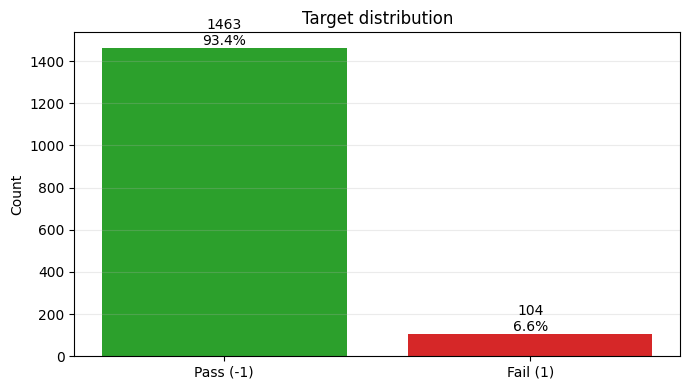

In [50]:
section("2. Анализ целевой переменной")

target_counts = (
    y.map({0: "Pass (-1)", 1: "Fail (1)"})
    .value_counts()
    .reindex(["Pass (-1)", "Fail (1)"])
)
target_table = pd.DataFrame({
    "count": target_counts,
    "share": target_counts / len(y),
})
display(target_table)

always_pass_pred = np.zeros_like(y)
always_pass_metrics = pd.DataFrame([{
    "strategy": "always_pass",
    "accuracy": accuracy_score(y, always_pass_pred),
    "balanced_accuracy": balanced_accuracy_score(y, always_pass_pred),
    "ber": 1 - balanced_accuracy_score(y, always_pass_pred),
    "recall_fail": recall_score(y, always_pass_pred, pos_label=1, zero_division=0),
    "f1_fail": f1_score(y, always_pass_pred, pos_label=1, zero_division=0),
}])
display(always_pass_metrics)

plt.figure(figsize=(7, 4))
bars = plt.bar(target_counts.index, target_counts.values, color=["#2ca02c", "#d62728"])
plt.title("Target distribution")
plt.ylabel("Count")
for bar, count in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, count, f"{count}\n{count / len(y):.1%}", ha="center", va="bottom")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


3. Анализ пропущенных значений


,missing_count,missing_rate,n_unique
sensor_157,1429,0.9119,128
sensor_292,1429,0.9119,92
sensor_293,1429,0.9119,138
sensor_158,1429,0.9119,138
sensor_492,1341,0.8558,226
sensor_358,1341,0.8558,20
sensor_220,1341,0.8558,69
sensor_085,1341,0.8558,97
sensor_517,1018,0.6496,543
sensor_518,1018,0.6496,542


,features_with_missing,features_with_missing_gt_50pct,rows_with_missing,total_missing_values
0,538,28,1567,41951


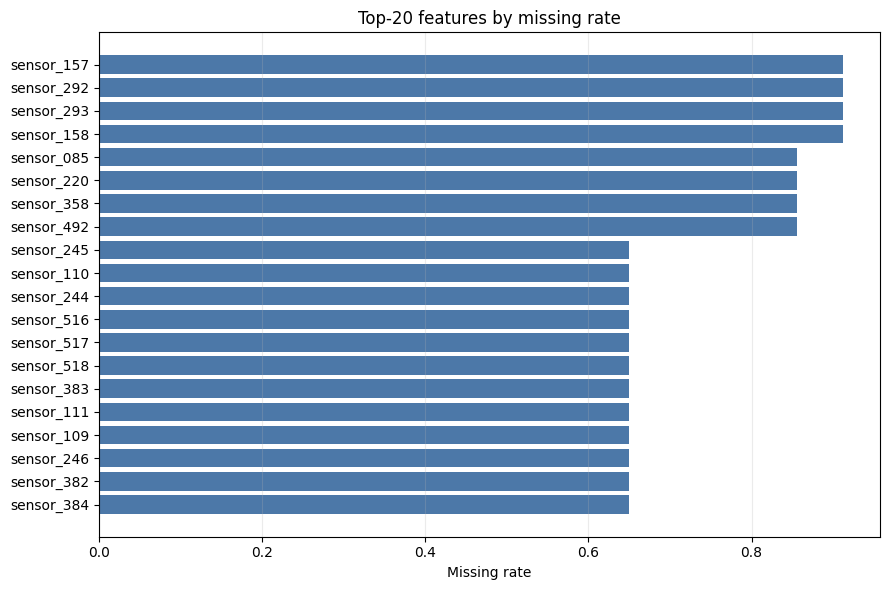

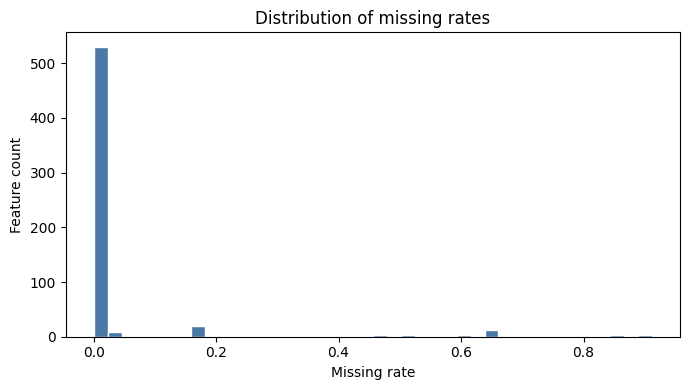

In [51]:
section("3. Анализ пропущенных значений")

missing_table = pd.DataFrame({
    "missing_count": X_raw.isna().sum(),
    "missing_rate": X_raw.isna().mean(),
    "n_unique": X_raw.nunique(dropna=True),
}).sort_values("missing_rate", ascending=False)

display(missing_table.head(30))

missing_summary = pd.DataFrame([{
    "features_with_missing": int((missing_table["missing_count"] > 0).sum()),
    "features_with_missing_gt_50pct": int((missing_table["missing_rate"] > 0.50).sum()),
    "rows_with_missing": int(X_raw.isna().any(axis=1).sum()),
    "total_missing_values": int(X_raw.isna().sum().sum()),
}])
display(missing_summary)

top_missing = missing_table.head(20).sort_values("missing_rate")
plt.figure(figsize=(9, 6))
plt.barh(top_missing.index, top_missing["missing_rate"], color="#4c78a8")
plt.xlabel("Missing rate")
plt.title("Top-20 features by missing rate")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(missing_table["missing_rate"], bins=40, color="#4c78a8", edgecolor="white")
plt.xlabel("Missing rate")
plt.ylabel("Feature count")
plt.title("Distribution of missing rates")
plt.tight_layout()
plt.show()


4. Распределение числовых признаков


,count,mean,std,min,25%,50%,75%,max
sensor_162,1565.0,4797.1546,6553.5693,0.0000,451.0000,1784.0000,6384.0000,36871.0000
sensor_161,1565.0,4066.8505,4239.2451,0.0000,1321.0000,2614.0000,5034.0000,37943.0000
sensor_297,1565.0,2342.8270,3226.9243,0.0000,210.9366,820.0988,3190.6164,18520.4683
sensor_024,1565.0,-298.5981,2902.6901,-14804.5000,-1476.0000,-78.7500,1377.2500,14106.0000
sensor_296,1565.0,1879.2284,1975.1114,0.0000,603.0329,1202.4121,2341.2887,15559.9525
sensor_023,1565.0,-3806.2997,1380.1621,-9986.7500,-4371.7500,-3820.7500,-3352.7500,2363.0000
sensor_159,1565.0,882.6805,983.0430,0.0000,411.0000,623.0000,966.0000,7791.0000
sensor_021,1565.0,-5618.3936,626.8222,-7150.2500,-5933.2500,-5523.2500,-5356.2500,0.0000
sensor_160,1565.0,555.3463,574.8086,0.0000,295.0000,438.0000,625.0000,4170.0000
sensor_204,1561.0,32.2182,565.1012,0.0429,0.1143,0.1582,0.2307,9998.4483


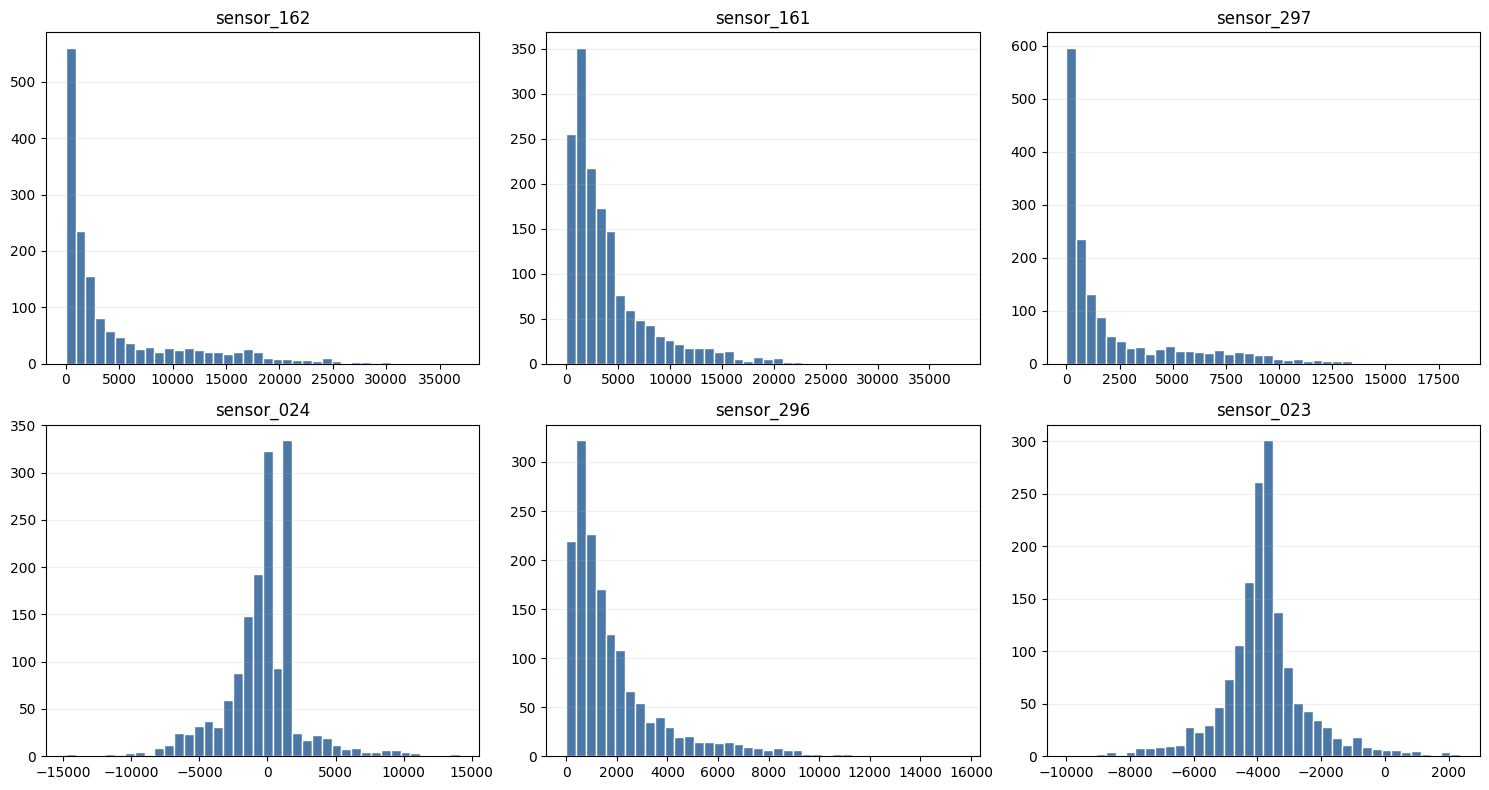

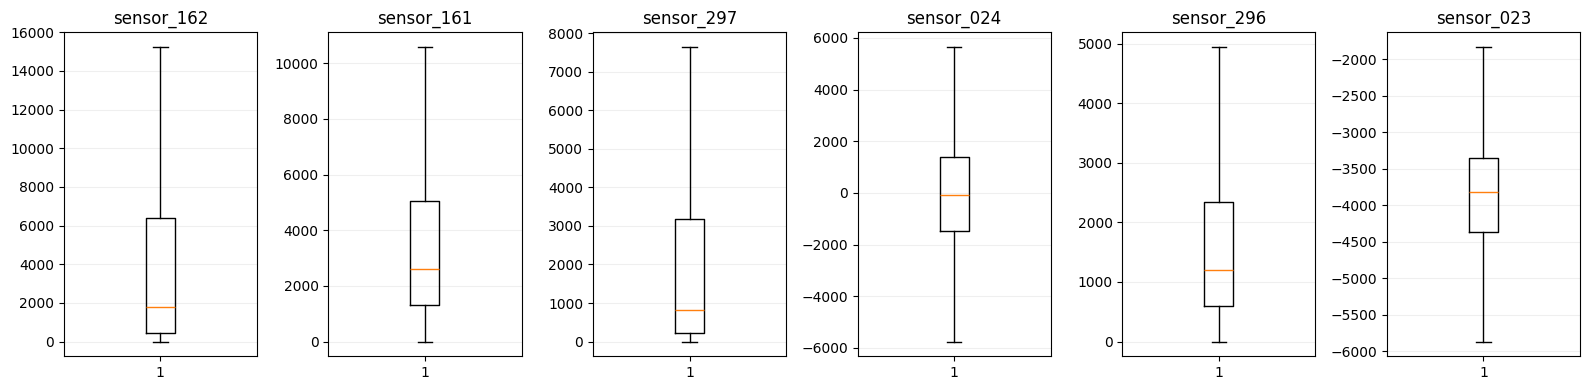

In [52]:
section("4. Распределение числовых признаков")

numeric_summary = X_raw.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
display(numeric_summary.sort_values("std", ascending=False).head(20))

top_std_features = numeric_summary.sort_values("std", ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, feature in zip(axes, top_std_features):
    ax.hist(X_raw[feature].dropna(), bins=40, color="#4c78a8", edgecolor="white")
    ax.set_title(feature)
    ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(top_std_features), figsize=(16, 4))
for ax, feature in zip(axes, top_std_features):
    ax.boxplot(X_raw[feature].dropna(), showfliers=False)
    ax.set_title(feature)
    ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


5. Корреляционный и статистический анализ: SelectKBest(f_classif)


,feature,f_score,p_value
54,sensor_059,39.0397,5.3411e-10
96,sensor_103,36.6300,1.7840e-09
409,sensor_510,27.6077,1.6904e-07
293,sensor_348,27.2439,2.0336e-07
351,sensor_431,22.8407,1.9251e-06
354,sensor_434,19.6341,1.0030e-05
350,sensor_430,18.8575,1.4990e-05
19,sensor_021,18.5852,1.7262e-05
355,sensor_435,18.5597,1.7492e-05
26,sensor_028,18.1209,2.1963e-05


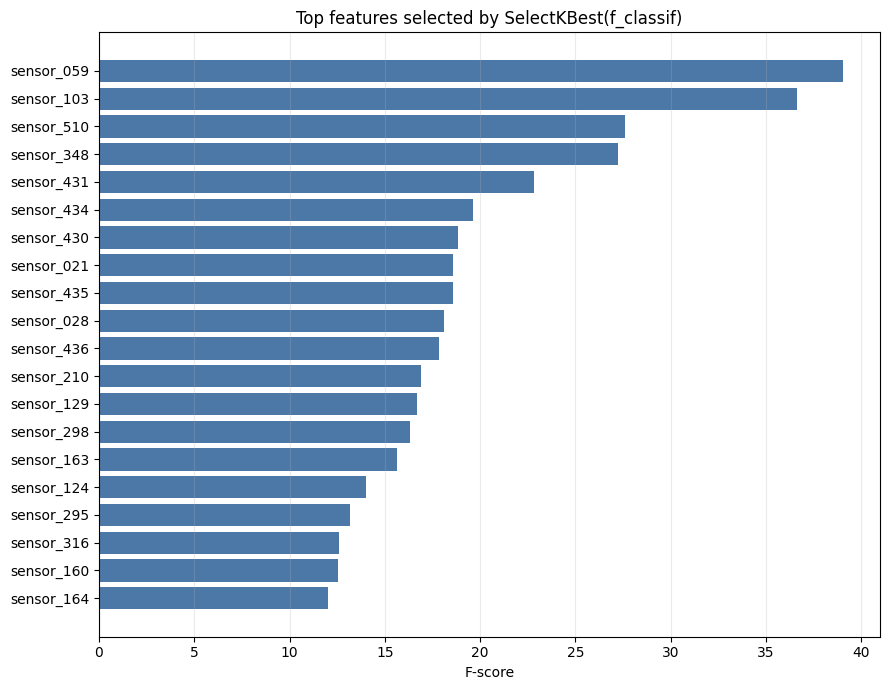

,target_correlation
sensor_059,0.1558
sensor_103,0.1512
sensor_510,0.1316
sensor_348,0.1302
sensor_431,0.1209
sensor_434,0.1121
sensor_430,0.1101
sensor_435,0.1091
sensor_021,0.1085
sensor_028,-0.1073


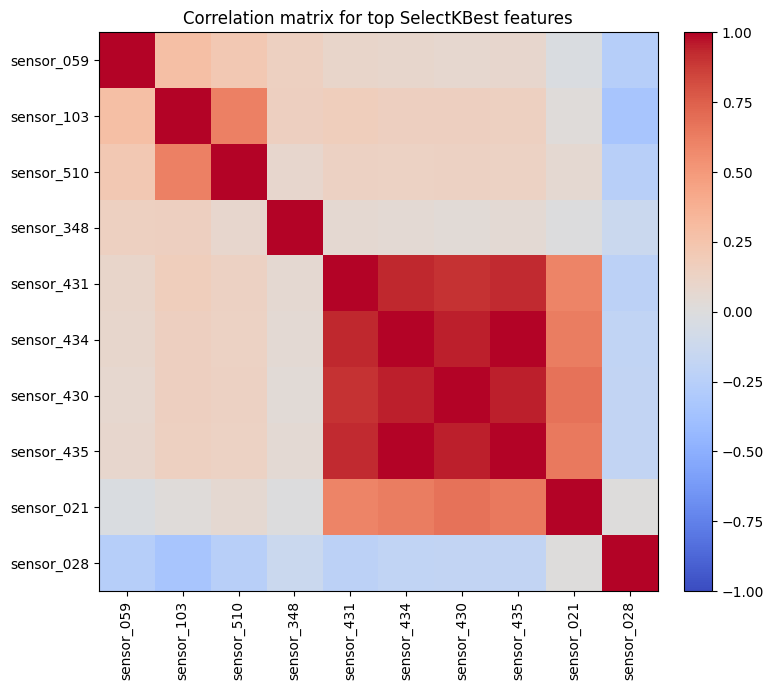

In [53]:
section("5. Корреляционный и статистический анализ: SelectKBest(f_classif)")

k_eda = 20
eda_imputer = SimpleImputer(strategy="median")
eda_variance = VarianceThreshold(threshold=0.0)
eda_selector = SelectKBest(score_func=f_classif, k=k_eda)

X_imputed = eda_imputer.fit_transform(X_raw)
X_nonconstant = eda_variance.fit_transform(X_imputed)
nonconstant_features = np.asarray(X_raw.columns)[eda_variance.get_support()]
eda_selector.fit(X_nonconstant, y)

select_table = pd.DataFrame({
    "feature": nonconstant_features,
    "f_score": eda_selector.scores_,
    "p_value": eda_selector.pvalues_,
}).sort_values("f_score", ascending=False)

selected_kbest_features = select_table.head(k_eda)["feature"].tolist()
display(select_table.head(k_eda))

plot_data = select_table.head(k_eda).sort_values("f_score")
plt.figure(figsize=(9, 7))
plt.barh(plot_data["feature"], plot_data["f_score"], color="#4c78a8")
plt.xlabel("F-score")
plt.title("Top features selected by SelectKBest(f_classif)")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

target_corr = X_raw[selected_kbest_features].corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)
display(pd.DataFrame({"target_correlation": target_corr}))

top_corr_features = target_corr.head(10).index.tolist()
corr_matrix = X_raw[top_corr_features].corr()

plt.figure(figsize=(8, 7))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(top_corr_features)), top_corr_features, rotation=90)
plt.yticks(range(len(top_corr_features)), top_corr_features)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Correlation matrix for top SelectKBest features")
plt.tight_layout()
plt.show()

In [54]:
section("6. Предобработка данных: импутация, кодирование, нормализация, инженерия признаков")

class SensorFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        x = np.asarray(X, dtype=float)
        self.n_features_in_ = x.shape[1]
        medians = np.nanmedian(x, axis=0)
        medians = np.where(np.isfinite(medians), medians, 0.0)
        imputed = np.where(np.isnan(x), medians, x)
        means = imputed.mean(axis=0)
        stds = imputed.std(axis=0)
        stds = np.where(stds > 1e-12, stds, 1.0)
        self.medians_ = medians
        self.means_ = means
        self.stds_ = stds
        return self

    def transform(self, X):
        x = np.asarray(X, dtype=float)
        missing_count = np.isnan(x).sum(axis=1).reshape(-1, 1)
        missing_rate = missing_count / max(1, x.shape[1])
        imputed = np.where(np.isnan(x), self.medians_, x)
        z = (imputed - self.means_) / self.stds_
        mean_abs_z = np.mean(np.abs(z), axis=1).reshape(-1, 1)
        max_abs_z = np.max(np.abs(z), axis=1).reshape(-1, 1)
        return np.hstack([x, missing_count, missing_rate, mean_abs_z, max_abs_z])

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = [f"sensor_{i:03d}" for i in range(self.n_features_in_)]
        return np.asarray(list(input_features) + ["missing_count", "missing_rate", "mean_abs_z", "max_abs_z"])


class MissingRateDropper(BaseEstimator, TransformerMixin):
    def __init__(self, max_missing_rate=0.50):
        self.max_missing_rate = max_missing_rate

    def fit(self, X, y=None):
        x = np.asarray(X, dtype=float)
        self.keep_mask_ = np.isnan(x).mean(axis=0) <= self.max_missing_rate
        if not np.any(self.keep_mask_):
            raise ValueError("All features were removed by MissingRateDropper.")
        return self

    def transform(self, X):
        return np.asarray(X, dtype=float)[:, self.keep_mask_]

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = [f"feature_{i}" for i in range(len(self.keep_mask_))]
        return np.asarray(input_features)[self.keep_mask_]


def make_feature_pipeline(k=40):
    return Pipeline([
        ("engineer", SensorFeatureEngineer()),
        ("drop_missing", MissingRateDropper(max_missing_rate=0.50)),
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=k)),
    ])


def make_model_pipeline(model, k=40):
    return Pipeline([
        ("engineer", SensorFeatureEngineer()),
        ("drop_missing", MissingRateDropper(max_missing_rate=0.50)),
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=k)),
        ("model", model),
    ])


def get_selected_feature_names(fitted_pipeline, input_features):
    names = np.asarray(input_features)
    names = fitted_pipeline.named_steps["engineer"].get_feature_names_out(names)
    names = fitted_pipeline.named_steps["drop_missing"].get_feature_names_out(names)
    names = names[fitted_pipeline.named_steps["variance"].get_support()]
    names = names[fitted_pipeline.named_steps["select"].get_support()]
    return np.asarray(names)


preprocessing_steps = pd.DataFrame([
    {"step": "engineering", "method": "missing_count, missing_rate, mean_abs_z, max_abs_z"},
    {"step": "missing columns", "method": "drop features with missing_rate > 0.50"},
    {"step": "imputation", "method": "median"},
    {"step": "constant features", "method": "VarianceThreshold(0.0)"},
    {"step": "encoding", "method": "not required; all features are numeric"},
    {"step": "normalization", "method": "StandardScaler"},
    {"step": "feature selection", "method": "SelectKBest(f_classif)"},
])
display(preprocessing_steps)


6. Предобработка данных: импутация, кодирование, нормализация, инженерия признаков


,step,method
0,engineering,"missing_count, missing_rate, mean_abs_z, max_a..."
1,missing columns,drop features with missing_rate > 0.50
2,imputation,median
3,constant features,VarianceThreshold(0.0)
4,encoding,not required; all features are numeric
5,normalization,StandardScaler
6,feature selection,SelectKBest(f_classif)


In [55]:
section("7. Разбивка данных на train и hold-out, 5-fold cross-validation на train")

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "recall_fail": make_scorer(recall_score, pos_label=1, zero_division=0),
    "precision_fail": make_scorer(precision_score, pos_label=1, zero_division=0),
    "f1_fail": make_scorer(f1_score, pos_label=1, zero_division=0),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

split_table = pd.DataFrame([
    {"split": "train", "n": len(y_train), "pass": int((y_train == 0).sum()), "fail": int((y_train == 1).sum()), "fail_rate": y_train.mean()},
    {"split": "holdout", "n": len(y_holdout), "pass": int((y_holdout == 0).sum()), "fail": int((y_holdout == 1).sum()), "fail_rate": y_holdout.mean()},
])
display(split_table)

searches = {}
model_summaries = []
cv_result_frames = []


7. Разбивка данных на train и hold-out, 5-fold cross-validation на train


,split,n,pass,fail,fail_rate
0,train,1253,1170,83,0.0662
1,holdout,314,293,21,0.0669


In [56]:
section("8. Итоговый набор признаков")

feature_pipeline = make_feature_pipeline(k=40)
feature_pipeline.fit(X_train, y_train)

selected_feature_names = get_selected_feature_names(feature_pipeline, X_raw.columns)
selected_feature_table = pd.DataFrame({
    "rank": np.arange(1, len(selected_feature_names) + 1),
    "feature": selected_feature_names,
})
display(selected_feature_table)

X_train_selected = feature_pipeline.transform(X_train)
feature_set_summary = pd.DataFrame([{
    "initial_features": X_raw.shape[1],
    "after_engineering": X_raw.shape[1] + 4,
    "after_drop_missing_and_variance": feature_pipeline.named_steps["variance"].get_support().sum(),
    "selected_features": X_train_selected.shape[1],
}])
display(feature_set_summary)


8. Итоговый набор признаков


,rank,feature
0,1,sensor_021
1,2,sensor_022
2,3,sensor_028
3,4,sensor_033
4,5,sensor_059
5,6,sensor_063
6,7,sensor_064
7,8,sensor_065
8,9,sensor_095
9,10,sensor_100


,initial_features,after_engineering,after_drop_missing_and_variance,selected_features
0,590,594,444,40


In [57]:
def metric_dict(y_true, y_pred, y_proba=None):
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": bal_acc,
        "BER": 1 - bal_acc,
        "Recall Fail": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Precision Fail": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1 Fail": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }
    if y_proba is not None and len(np.unique(y_true)) == 2:
        result["ROC AUC"] = roc_auc_score(y_true, y_proba)
        result["Average Precision"] = average_precision_score(y_true, y_proba)
    else:
        result["ROC AUC"] = np.nan
        result["Average Precision"] = np.nan
    return result


def get_preprocessor(fitted_pipeline):
    return Pipeline(fitted_pipeline.steps[:-1])


def plot_best_model_projection(fitted_pipeline, X_fit, y_fit, X_plot, y_plot, title):
    preprocessor = get_preprocessor(fitted_pipeline)
    X_fit_prepared = preprocessor.transform(X_fit)
    X_plot_prepared = preprocessor.transform(X_plot)
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca.fit(X_fit_prepared)
    z = pca.transform(X_plot_prepared)
    pred = fitted_pipeline.predict(X_plot)
    colors = np.where(np.asarray(y_plot) == 0, "#2ca02c", "#d62728")
    labels = np.where(np.asarray(y_plot) == 0, "Pass", "Fail")

    plt.figure(figsize=(7, 5))
    for cls, color, label in [(0, "#2ca02c", "Pass"), (1, "#d62728", "Fail")]:
        mask = np.asarray(y_plot) == cls
        plt.scatter(z[mask, 0], z[mask, 1], c=color, label=label, alpha=0.75, s=42)
    wrong = pred != np.asarray(y_plot)
    if np.any(wrong):
        plt.scatter(z[wrong, 0], z[wrong, 1], facecolors="none", edgecolors="black", s=95, linewidths=1.5, label="Wrong")
    plt.title(title)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def run_hypothesis(algorithm, model, param_grid):
    search = GridSearchCV(
        estimator=make_model_pipeline(model),
        param_grid=param_grid,
        scoring=scoring,
        refit="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
        verbose=0,
    )
    search.fit(X_train, y_train)

    result = pd.DataFrame(search.cv_results_)
    result["algorithm"] = algorithm
    result["BER"] = 1 - result["mean_test_balanced_accuracy"]
    cv_result_frames.append(result)
    searches[algorithm] = search

    best = result.loc[search.best_index_]
    summary = {
        "algorithm": algorithm,
        "Balanced Accuracy": best["mean_test_balanced_accuracy"],
        "BER": 1 - best["mean_test_balanced_accuracy"],
        "Recall Fail": best["mean_test_recall_fail"],
        "F1 Fail": best["mean_test_f1_fail"],
        "ROC AUC": best["mean_test_roc_auc"],
        "best_params": search.best_params_,
    }
    model_summaries.append(summary)
    display(pd.DataFrame([summary]))

    plot_best_model_projection(
        search.best_estimator_,
        X_train,
        y_train,
        X_holdout,
        y_holdout,
        f"{algorithm}: hold-out PCA projection",
    )
    return search



9.1 H1: Logistic Regression


,algorithm,Balanced Accuracy,BER,Recall Fail,F1 Fail,ROC AUC,best_params
0,logistic_regression,0.6658,0.3342,0.5897,0.2308,0.6929,"{'model__C': 0.1, 'model__penalty': 'l1', 'sel..."


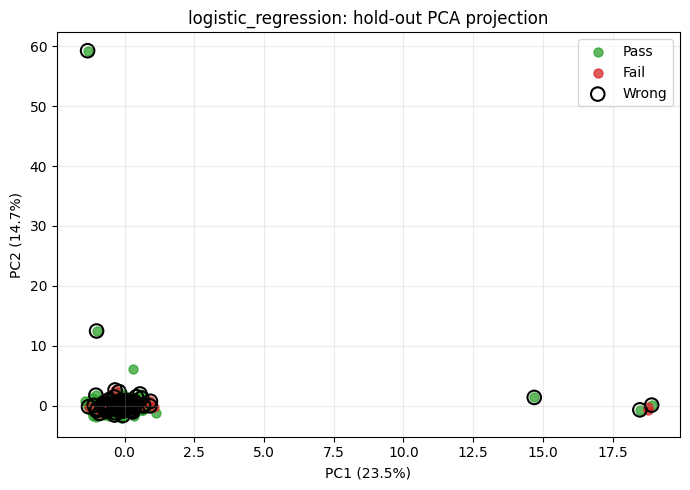

In [58]:
section("9.1 H1: Logistic Regression")

logreg_search = run_hypothesis(
    "logistic_regression",
    LogisticRegression(
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE,
    ),
    {
      "select__k": [20, 40, 80, 120],
        "model__C": [0.01, 0.1, 1.0, 10.0],
        "model__penalty": ["l1", "l2"],
    },
)


9.2 H2: Gaussian Naive Bayes


,algorithm,Balanced Accuracy,BER,Recall Fail,F1 Fail,ROC AUC,best_params
0,gaussian_naive_bayes,0.5389,0.4611,0.1316,0.1387,0.6876,"{'model__var_smoothing': 1e-09, 'select__k': 10}"


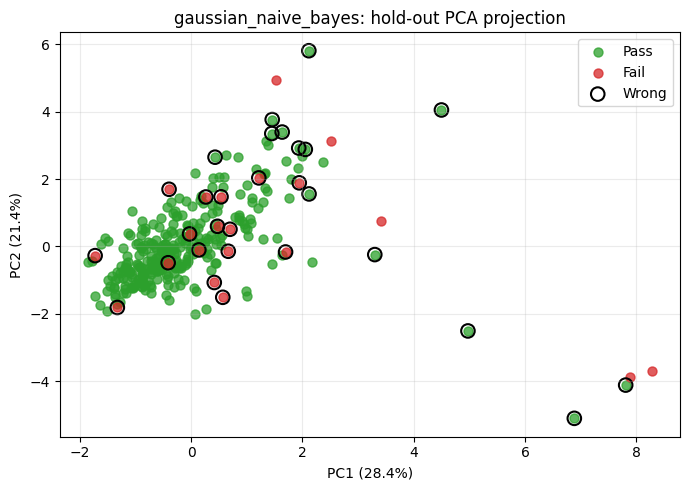

In [59]:
section("9.2 H2: Gaussian Naive Bayes")

gnb_search = run_hypothesis(
    "gaussian_naive_bayes",
    GaussianNB(),
    {
      "select__k": [10, 20, 40, 80],
        "model__var_smoothing": [1e-9, 1e-6, 1e-3],
    },
)


9.3 H3: KNN


,algorithm,Balanced Accuracy,BER,Recall Fail,F1 Fail,ROC AUC,best_params
0,knn,0.548,0.452,0.1088,0.1673,0.5654,"{'model__n_neighbors': 3, 'model__weights': 'u..."


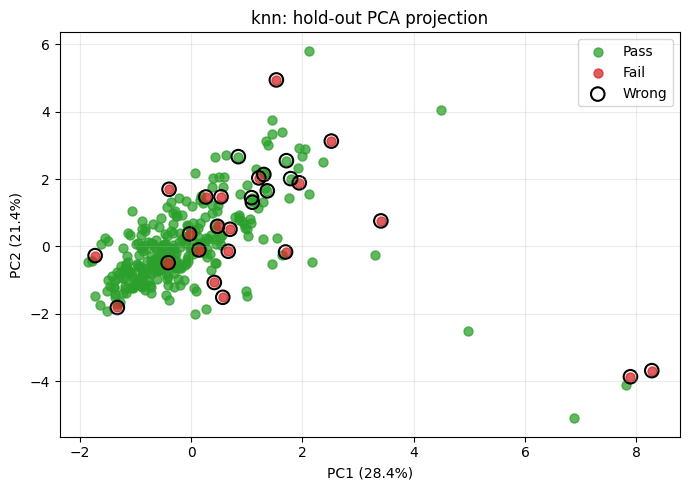

In [60]:
section("9.3 H3: KNN")

knn_search = run_hypothesis(
    "knn",
    KNeighborsClassifier(),
    {
      "select__k": [10, 20, 40],
        "model__n_neighbors": [3, 5, 11, 25],
        "model__weights": ["uniform", "distance"],
    },
)


9.4 H4: Decision Tree


,algorithm,Balanced Accuracy,BER,Recall Fail,F1 Fail,ROC AUC,best_params
0,decision_tree,0.6307,0.3693,0.5529,0.1942,0.649,"{'model__max_depth': 4, 'model__min_samples_le..."


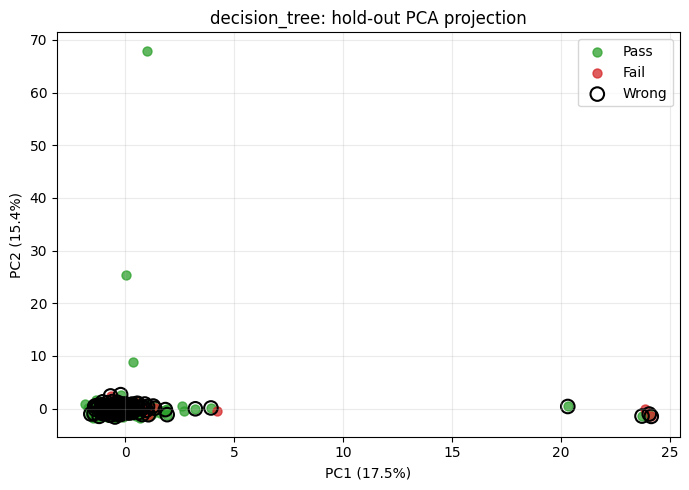

In [61]:
section("9.4 H4: Decision Tree")

tree_search = run_hypothesis(
    "decision_tree",
    DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    {
      "select__k": [10, 20, 40, 80],
        "model__max_depth": [2, 3, 4, 5],
        "model__min_samples_leaf": [10, 20, 40],
    },
)


9.5 H5: Random Forest


,algorithm,Balanced Accuracy,BER,Recall Fail,F1 Fail,ROC AUC,best_params
0,random_forest,0.5791,0.4209,0.2735,0.1857,0.6942,"{'model__max_depth': 3, 'model__max_features':..."


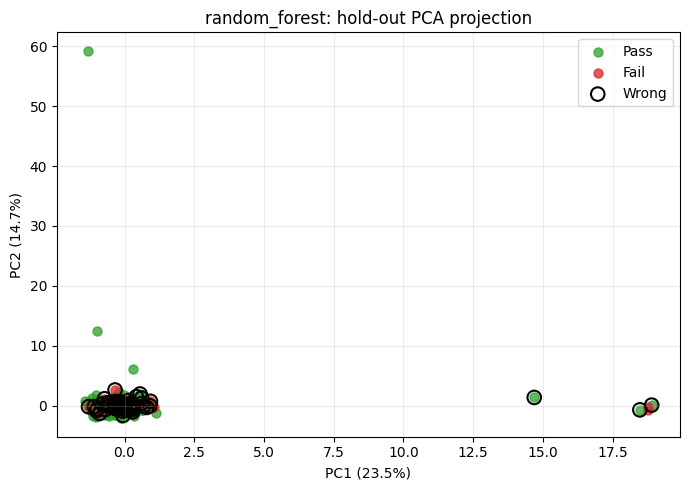

In [62]:
section("9.5 H5: Random Forest")

rf_search = run_hypothesis(
    "random_forest",
    RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    {
      "select__k": [40, 80, 120],
        "model__max_depth": [3, 5, None],
        "model__min_samples_leaf": [5, 20],
        "model__max_features": ["sqrt", 0.25],
    },
)


9.6 H6: CatBoost


,algorithm,Balanced Accuracy,BER,Recall Fail,F1 Fail,ROC AUC,best_params
0,catboost,0.5854,0.4146,0.275,0.1972,0.6772,"{'model__depth': 3, 'model__iterations': 300, ..."


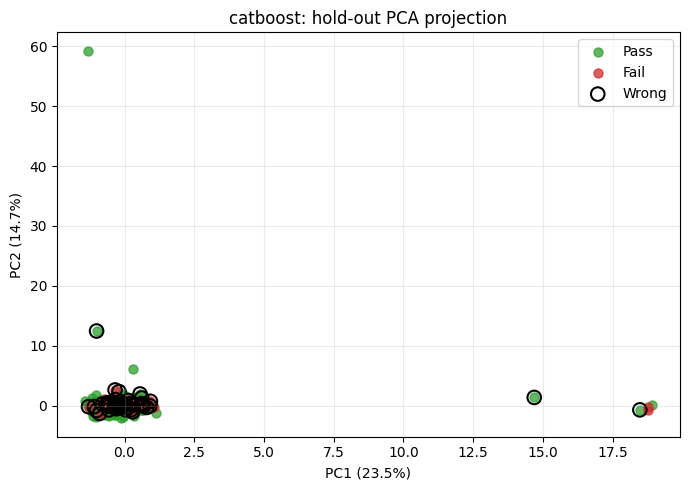

In [63]:
section("9.6 H6: CatBoost")

if CATBOOST_AVAILABLE:
    catboost_search = run_hypothesis(
        "catboost",
        CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        ),
        {
            "select__k": [40, 80],
            "model__iterations": [300, 900, 1500],
            "model__depth": [3, 4, 5, 6],
            "model__learning_rate": [0.03, 0.05],
            "model__l2_leaf_reg": [1, 3, 10],
        },
    )


10. Итоговая таблица


,algorithm,Balanced Accuracy,BER,Recall Fail,F1 Fail,ROC AUC,best_params
0,logistic_regression,0.6658,0.3342,0.5897,0.2308,0.6929,"{'model__C': 0.1, 'model__penalty': 'l1', 'sel..."
1,decision_tree,0.6307,0.3693,0.5529,0.1942,0.6490,"{'model__max_depth': 4, 'model__min_samples_le..."
2,catboost,0.5854,0.4146,0.2750,0.1972,0.6772,"{'model__depth': 3, 'model__iterations': 300, ..."
3,random_forest,0.5791,0.4209,0.2735,0.1857,0.6942,"{'model__max_depth': 3, 'model__max_features':..."
4,knn,0.5480,0.4520,0.1088,0.1673,0.5654,"{'model__n_neighbors': 3, 'model__weights': 'u..."
5,gaussian_naive_bayes,0.5389,0.4611,0.1316,0.1387,0.6876,"{'model__var_smoothing': 1e-09, 'select__k': 10}"


,selection_metric,algorithm,Balanced Accuracy,BER,Recall Fail,F1 Fail,ROC AUC,best_params
0,F1 Fail,logistic_regression,0.6658,0.3342,0.5897,0.2308,0.6929,"{'model__C': 0.1, 'model__penalty': 'l1', 'sel..."
1,Recall Fail,logistic_regression,0.6658,0.3342,0.5897,0.2308,0.6929,"{'model__C': 0.1, 'model__penalty': 'l1', 'sel..."
2,Balanced Accuracy,logistic_regression,0.6658,0.3342,0.5897,0.2308,0.6929,"{'model__C': 0.1, 'model__penalty': 'l1', 'sel..."
3,BER,logistic_regression,0.6658,0.3342,0.5897,0.2308,0.6929,"{'model__C': 0.1, 'model__penalty': 'l1', 'sel..."
4,ROC AUC,random_forest,0.5791,0.4209,0.2735,0.1857,0.6942,"{'model__max_depth': 3, 'model__max_features':..."


,algorithm,mean_test_balanced_accuracy,BER,mean_test_recall_fail,mean_test_f1_fail,mean_test_roc_auc,params
9,logistic_regression,0.6658,0.3342,0.5897,0.2308,0.6929,"{'model__C': 0.1, 'model__penalty': 'l1', 'sel..."
4,logistic_regression,0.6566,0.3434,0.6029,0.2172,0.6937,"{'model__C': 0.01, 'model__penalty': 'l2', 'se..."
2,logistic_regression,0.6490,0.3510,0.6757,0.1942,0.6924,"{'model__C': 0.01, 'model__penalty': 'l1', 'se..."
3,logistic_regression,0.6490,0.3510,0.6757,0.1942,0.6924,"{'model__C': 0.01, 'model__penalty': 'l1', 'se..."
1,logistic_regression,0.6490,0.3510,0.6757,0.1942,0.6924,"{'model__C': 0.01, 'model__penalty': 'l1', 'se..."
0,logistic_regression,0.6490,0.3510,0.6757,0.1942,0.6924,"{'model__C': 0.01, 'model__penalty': 'l1', 'se..."
5,logistic_regression,0.6466,0.3534,0.5897,0.2072,0.6791,"{'model__C': 0.01, 'model__penalty': 'l2', 'se..."
14,logistic_regression,0.6434,0.3566,0.5287,0.2165,0.6686,"{'model__C': 0.1, 'model__penalty': 'l2', 'sel..."
8,logistic_regression,0.6430,0.3570,0.5544,0.2105,0.6959,"{'model__C': 0.1, 'model__penalty': 'l1', 'sel..."
30,logistic_regression,0.6425,0.3575,0.4926,0.2239,0.6758,"{'model__C': 10.0, 'model__penalty': 'l2', 'se..."


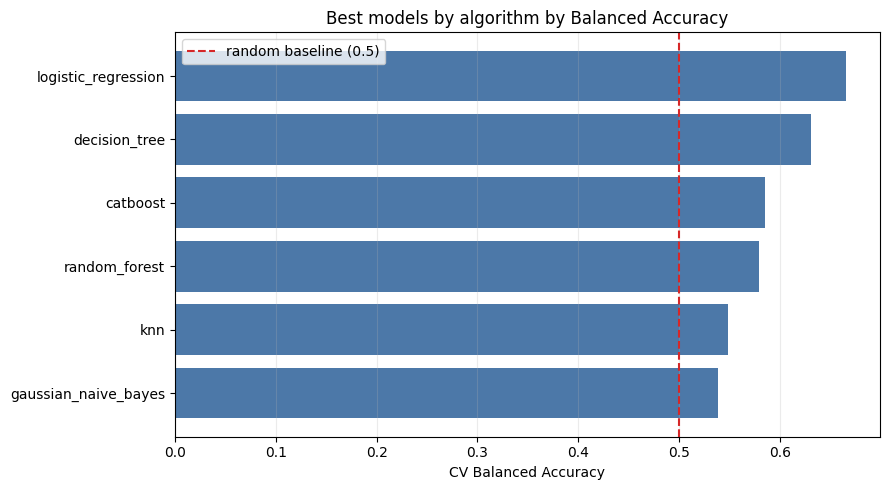

In [64]:
section("10. Итоговая таблица")

model_results = (
    pd.DataFrame(model_summaries)
    .sort_values(["Balanced Accuracy", "F1 Fail", "Recall Fail"], ascending=False)
    .reset_index(drop=True)
)
display(model_results)

metric_leaders = []
for metric_name, ascending in [
    ("F1 Fail", False),
    ("Recall Fail", False),
    ("Balanced Accuracy", False),
    ("BER", True),
    ("ROC AUC", False),
]:
    row = model_results.sort_values(metric_name, ascending=ascending).iloc[0].to_dict()
    row["selection_metric"] = metric_name
    metric_leaders.append(row)

metric_leaders = pd.DataFrame(metric_leaders)[
    ["selection_metric", "algorithm", "Balanced Accuracy", "BER", "Recall Fail", "F1 Fail", "ROC AUC", "best_params"]
]
display(metric_leaders)

cv_results = pd.concat(cv_result_frames, ignore_index=True)
display(
    cv_results.sort_values("mean_test_balanced_accuracy", ascending=False)[
        [
            "algorithm",
            "mean_test_balanced_accuracy",
            "BER",
            "mean_test_recall_fail",
            "mean_test_f1_fail",
            "mean_test_roc_auc",
            "params",
        ]
    ].head(20)
)

plt.figure(figsize=(9, 5))
plot_table = model_results.sort_values("Balanced Accuracy")
plt.barh(plot_table["algorithm"], plot_table["Balanced Accuracy"], color="#4c78a8")
plt.axvline(0.5, color="#d62728", linestyle="--", label="random baseline (0.5)")
plt.xlabel("CV Balanced Accuracy")
plt.title("Best models by algorithm by Balanced Accuracy")
plt.legend()
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


11. Метрики лучшей модели на hold-out выборке


,algorithm,Accuracy,Balanced Accuracy,BER,Recall Fail,Precision Fail,F1 Fail,ROC AUC,Average Precision
0,logistic_regression,0.7611,0.651,0.349,0.5238,0.1447,0.2268,0.7153,0.2764


,Predicted Pass,Predicted Fail
Actual Pass,228,65
Actual Fail,10,11


              precision    recall  f1-score   support

        Pass       0.96      0.78      0.86       293
        Fail       0.14      0.52      0.23        21

    accuracy                           0.76       314
   macro avg       0.55      0.65      0.54       314
weighted avg       0.90      0.76      0.82       314



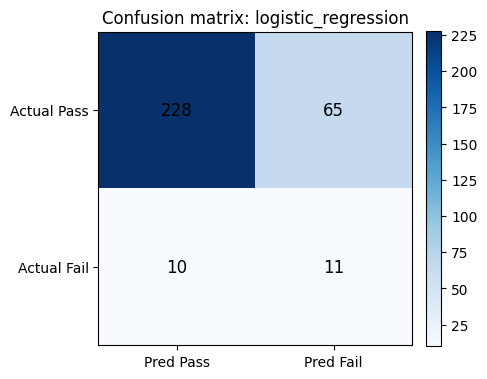

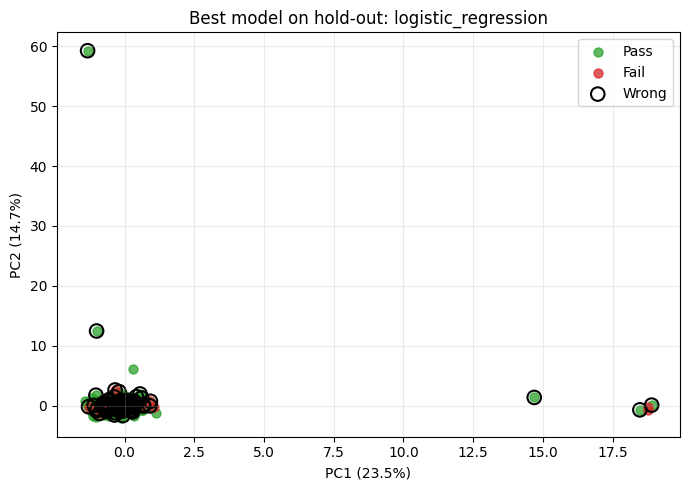

In [ ]:
section("11. Метрики лучшей модели на hold-out выборке")

best_algorithm = model_results.iloc[0]["algorithm"]
best_model = searches[best_algorithm].best_estimator_

# Baseline predictions (threshold = 0.5)
if hasattr(best_model, "predict_proba"):
    holdout_proba = best_model.predict_proba(X_holdout)[:, 1]
else:
    holdout_proba = None

if holdout_proba is not None:
    holdout_pred = (holdout_proba >= 0.5).astype(int)
else:
    holdout_pred = best_model.predict(X_holdout)

holdout_metrics = metric_dict(y_holdout, holdout_pred, holdout_proba)
holdout_metrics_table = pd.DataFrame([{"algorithm": best_algorithm, "threshold": 0.5, **holdout_metrics}])
display(holdout_metrics_table)

cm = confusion_matrix(y_holdout, holdout_pred)
display(pd.DataFrame(cm, index=["Actual Pass", "Actual Fail"], columns=["Predicted Pass", "Predicted Fail"]))

print(classification_report(y_holdout, holdout_pred, target_names=["Pass", "Fail"], zero_division=0))

plt.figure(figsize=(4.8, 4.2))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion matrix: {best_algorithm} (threshold=0.5)")
plt.xticks([0, 1], ["Pred Pass", "Pred Fail"])
plt.yticks([0, 1], ["Actual Pass", "Actual Fail"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Threshold tuning using out-of-fold (OOF) probabilities on train
from sklearn.model_selection import cross_val_predict
if hasattr(best_model, "predict_proba"):
    train_oof_proba = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
elif hasattr(best_model, "decision_function"):
    train_oof_scores = cross_val_predict(best_model, X_train, y_train, cv=cv, method="decision_function", n_jobs=-1)
    train_oof_proba = (train_oof_scores - train_oof_scores.min()) / (train_oof_scores.max() - train_oof_scores.min())
else:
    raise RuntimeError("Model does not support predict_proba or decision_function for threshold tuning.")

thresholds = np.linspace(0.01, 0.99, 99)
scores = [balanced_accuracy_score(y_train, (train_oof_proba >= t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(scores))
best_thresh = float(thresholds[best_idx])
best_score = float(scores[best_idx])

plt.figure(figsize=(7, 4))
plt.plot(thresholds, scores, marker="o")
plt.axvline(best_thresh, color="red", linestyle="--", label=f"best threshold={best_thresh:.3f}")
plt.xlabel("Threshold")
plt.ylabel("CV Balanced Accuracy (OOF)")
plt.title("Threshold tuning (OOF on training set)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best OOF threshold by Balanced Accuracy: {best_thresh:.3f} (OOF score={best_score:.4f})")

# Apply chosen threshold to hold-out
if holdout_proba is not None:
    holdout_pred_opt = (holdout_proba >= best_thresh).astype(int)
else:
    holdout_pred_opt = best_model.predict(X_holdout)

holdout_metrics_opt = metric_dict(y_holdout, holdout_pred_opt, holdout_proba)
holdout_metrics_table_opt = pd.DataFrame([{"algorithm": best_algorithm, "threshold": best_thresh, **holdout_metrics_opt}])
display(holdout_metrics_table_opt)

cm_opt = confusion_matrix(y_holdout, holdout_pred_opt)
display(pd.DataFrame(cm_opt, index=["Actual Pass", "Actual Fail"], columns=["Predicted Pass", "Predicted Fail"]))

print(classification_report(y_holdout, holdout_pred_opt, target_names=["Pass", "Fail"], zero_division=0))

plt.figure(figsize=(4.8, 4.2))
plt.imshow(cm_opt, cmap="Blues")
plt.title(f"Confusion matrix: {best_algorithm} (threshold={best_thresh:.3f})")
plt.xticks([0, 1], ["Pred Pass", "Pred Fail"])
plt.yticks([0, 1], ["Actual Pass", "Actual Fail"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_opt[i, j], ha="center", va="center", color="black", fontsize=12)
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

plot_best_model_projection(
    best_model,
    X_train,
    y_train,
    X_holdout,
    y_holdout,
    f"Best model on hold-out: {best_algorithm} (threshold={best_thresh:.3f})",
)


12. Суррогатное дерево


,best_algorithm,surrogate_fidelity_on_train_predictions,n_surrogate_features
0,logistic_regression,0.8747,40


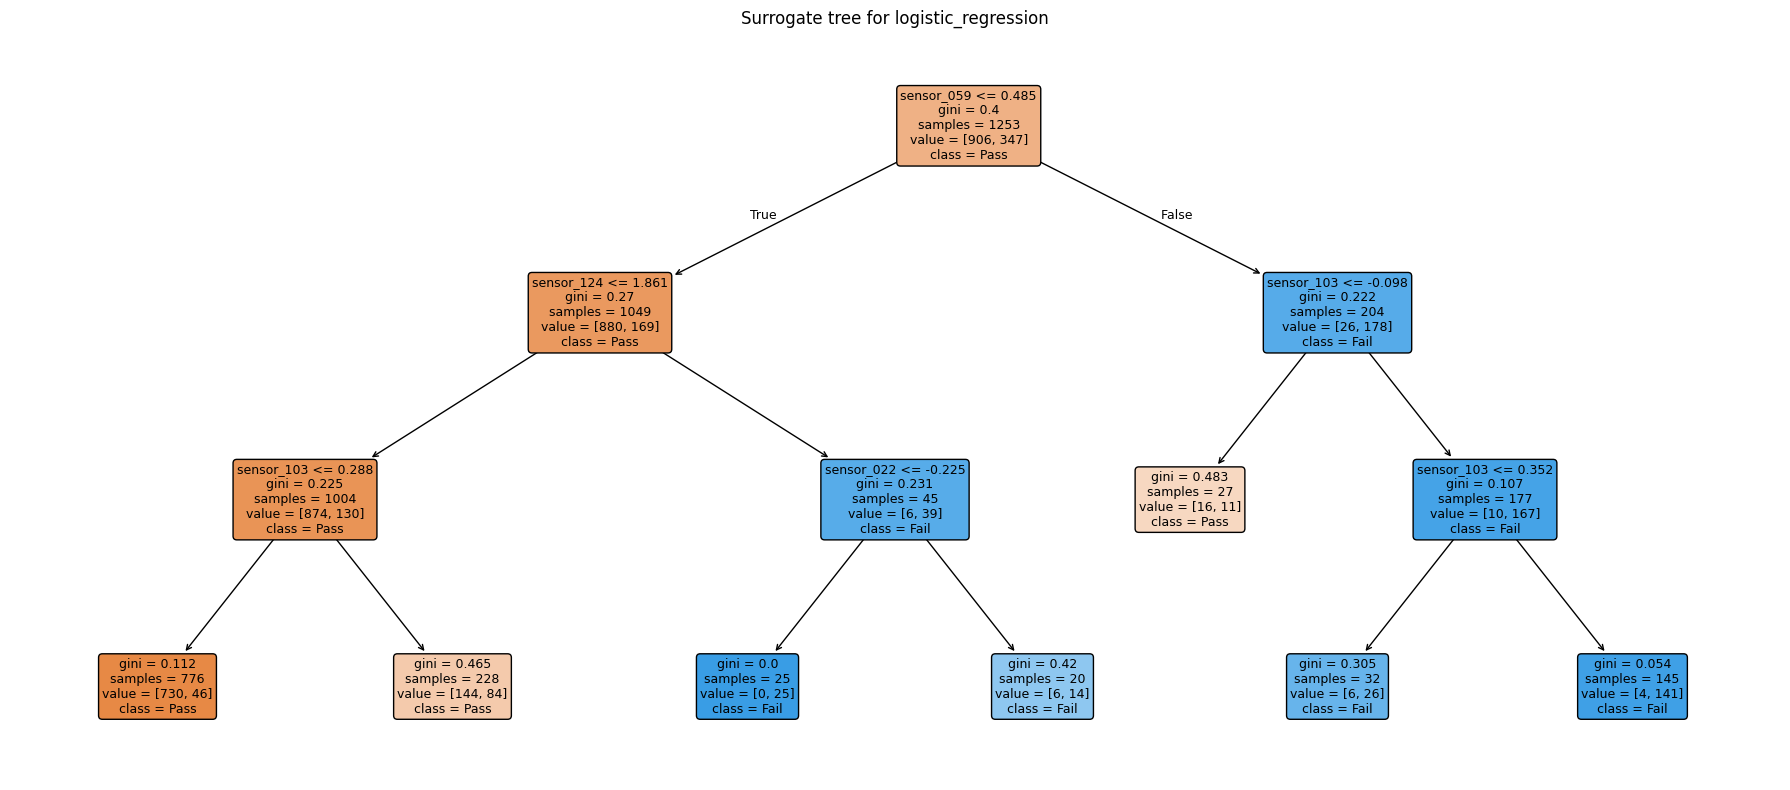

|--- sensor_059 <= 0.49
|   |--- sensor_124 <= 1.86
|   |   |--- sensor_103 <= 0.29
|   |   |   |--- class: 0
|   |   |--- sensor_103 >  0.29
|   |   |   |--- class: 0
|   |--- sensor_124 >  1.86
|   |   |--- sensor_022 <= -0.22
|   |   |   |--- class: 1
|   |   |--- sensor_022 >  -0.22
|   |   |   |--- class: 1
|--- sensor_059 >  0.49
|   |--- sensor_103 <= -0.10
|   |   |--- class: 0
|   |--- sensor_103 >  -0.10
|   |   |--- sensor_103 <= 0.35
|   |   |   |--- class: 1
|   |   |--- sensor_103 >  0.35
|   |   |   |--- class: 1



In [66]:
section("12. Суррогатное дерево")

best_preprocessor = get_preprocessor(best_model)
X_train_best = best_preprocessor.transform(X_train)
best_train_pred = best_model.predict(X_train)
best_feature_names = get_selected_feature_names(best_model, X_raw.columns)

surrogate_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
)
surrogate_tree.fit(X_train_best, best_train_pred)
surrogate_pred = surrogate_tree.predict(X_train_best)
surrogate_fidelity = accuracy_score(best_train_pred, surrogate_pred)

display(pd.DataFrame([{
    "best_algorithm": best_algorithm,
    "surrogate_fidelity_on_train_predictions": surrogate_fidelity,
    "n_surrogate_features": len(best_feature_names),
}]))

plt.figure(figsize=(18, 8))
plot_tree(
    surrogate_tree,
    feature_names=best_feature_names,
    class_names=["Pass", "Fail"],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title(f"Surrogate tree for {best_algorithm}")
plt.tight_layout()
plt.show()

print(export_text(surrogate_tree, feature_names=list(best_feature_names)))